# Component 1 — Classical Data Generation
### AI Design of Quantum Processors · Mondragon-Shem Quantum Group (UIC)
**Author:** Marcos Sandoval Lucas

**Goal of this component.** Simulate the classical harmonic oscillator (a mass on a spring) and generate the *classical baseline data* — energy structure and phase-space trajectories — that will later become **inputs** to the machine-learning model in Component 3.

**What you will do here**
- **Task 1:** state the energy function, derive the equations of motion, and map the energy in phase space.
- **Task 2:** numerically integrate the motion and plot trajectories for many starting conditions.

> **Why the harmonic oscillator?** It is *exactly solvable*, so every numerical result can be checked against a known formula. That is our safety net: *never trust a number you cannot verify.*

> **Sources.** Classical Hamiltonian mechanics here follows Susskind's *Theoretical Minimum* and Tong's *Classical Dynamics*. The quantum companion (Component 2) follows group's text, Essler's *Lecture Notes for Quantum Mechanics*. 

## Setup and conventions

We work in **natural units** $\hbar = m = \omega = 1$. This is standard in quantum simulation and makes sanity-checks clean (for example, quantum energy levels will come out as $0.5, 1.5, 2.5,\dots$).

A consequence for the *classical* part: the energy
$$E(x,p)=\frac{p^2}{2m}+\tfrac12 m\omega^2 x^2 \;\xrightarrow{\;m=\omega=1\;}\; \frac{p^2+x^2}{2}.$$
So constant-energy contours, which are **ellipses** in general units, become **circles** here. (With real $m,\omega$ they would be ellipses — same physics, just stretched axes.)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from oscillator import setup     # shared helper module (lives in shared/, importable anywhere)

# --- Natural units: hbar = m = omega = 1 ---
m = 1.0       # mass (dimensionless)
omega = 1.0   # angular frequency (dimensionless)

setup()       # group plot style + output routing (figures/ data/ movies/) in one call

Setup ready: group plot style applied, outputs route to figures/ data/ movies/.


---
# Task 1 — Energy and phase space

### (a) The classical energy function
The total energy of a 1-D harmonic oscillator, written in terms of position $x$ and momentum $p$, is
$$\boxed{\,E(x,p)=\frac{p^{2}}{2m}+\frac12 m\omega^{2}x^{2}\,}$$
- First term $p^2/2m$ — **kinetic energy** (energy of motion).
- Second term $\tfrac12 m\omega^2 x^2$ — **potential energy** stored in the spring.

When we treat this energy as the function that *generates the dynamics*, we call it the **Hamiltonian** $H(x,p)$. Same expression, deeper role.


In [2]:
def energy(x, p, m=m, omega=omega):
    '''Classical energy (Hamiltonian) of the harmonic oscillator.

    E = kinetic (p^2 / 2m) + potential (1/2 m omega^2 x^2).
    Works on scalars or NumPy arrays (for grids).
    '''
    kinetic = p**2 / (2.0 * m)
    potential = 0.5 * m * omega**2 * x**2
    return kinetic + potential

# Quick check at a known point: E(1, 0) should equal 1/2 in natural units.
print("E(x=1, p=0) =", energy(1.0, 0.0), " (expected 0.5)")
print("E(x=0, p=1) =", energy(0.0, 1.0), " (expected 0.5)")

E(x=1, p=0) = 0.5  (expected 0.5)
E(x=0, p=1) = 0.5  (expected 0.5)


### (b) Deriving the equations of motion (Hamilton's equations)
Hamilton's equations turn the energy into motion:
$$\dot{x}=\frac{\partial H}{\partial p},\qquad \dot{p}=-\frac{\partial H}{\partial x}.$$
Evaluating the partial derivatives of $H=\dfrac{p^2}{2m}+\tfrac12 m\omega^2 x^2$:
$$\dot{x}=\frac{p}{m},\qquad \dot{p}=-m\omega^{2}x.$$

**Reading these:** the first just says *velocity = momentum / mass*. The second says *force = $-m\omega^2 x$* (Hooke's law). Combining them — differentiate the first and substitute the second — recovers the familiar second-order equation
$$\ddot{x}=-\omega^{2}x,$$
whose solution is a sine/cosine oscillation. We keep the **first-order pair** because that is exactly what a numerical ODE solver wants.


### (c) Mapping the energy in phase space
**Phase space** is the plane with position $x$ on one axis and momentum $p$ on the other. A single point there fully specifies the classical state. Because energy is conserved, the system is locked onto one constant-energy contour. We now draw those contours.


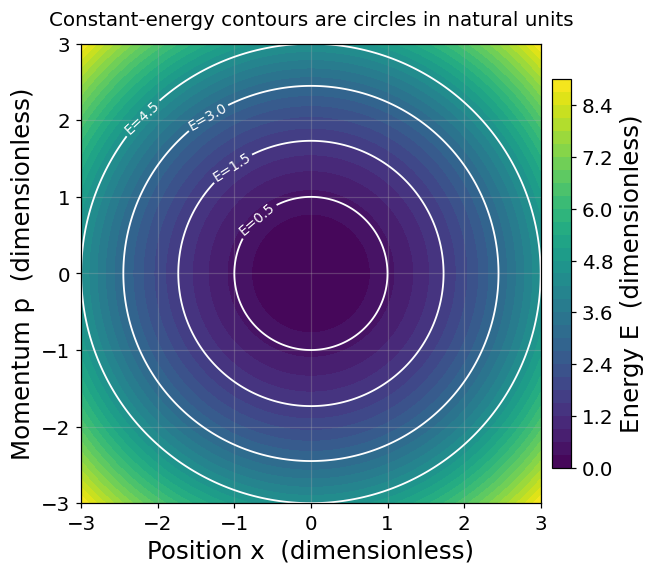

In [3]:
# Build a grid over phase space and evaluate the energy on it.
x_vals = np.linspace(-3, 3, 400)      # position axis (dimensionless)
p_vals = np.linspace(-3, 3, 400)      # momentum axis (dimensionless)
X, P = np.meshgrid(x_vals, p_vals)    # 2D grids of x and p
E_grid = energy(X, P)                 # energy at every (x, p)

fig, ax = plt.subplots(figsize=(6.2, 5.4))
# Filled contour = smooth energy landscape; 'viridis' is perceptually uniform.
filled = ax.contourf(X, P, E_grid, levels=30, cmap="viridis")
# Line contours mark specific constant-energy curves (the allowed orbits).
lines = ax.contour(X, P, E_grid, levels=[0.5, 1.5, 3.0, 4.5],
                   colors="white", linewidths=1.2)
ax.clabel(lines, inline=True, fontsize=9, fmt="E=%.1f")

cbar = fig.colorbar(filled, ax=ax, shrink=0.82, pad=0.02)
cbar.set_label("Energy E  (dimensionless)")
ax.set_xlabel("Position x  (dimensionless)")
ax.set_ylabel("Momentum p  (dimensionless)")
ax.set_title("Constant-energy contours are circles in natural units", fontsize=13, pad=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("fig_c1_energy_contours.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption.** *Energy of the classical harmonic oscillator over phase space. Color shows total energy $E(x,p)$; white curves are constant-energy contours. The contours are concentric circles (ellipses in general units), confirming that a classical oscillator of fixed energy is confined to a closed orbit and can never reach a region of different energy — this is energy conservation drawn as a picture.*

**Why circles?** Setting $E(x,p)=\tfrac12(x^2+p^2)=\text{const}$ is the equation of a circle. Larger energy → larger circle. The oscillator endlessly traces its own circle.


---
# Task 2 — Dynamics and trajectories

The contours show *where* the oscillator is allowed to be. Now we compute *how it actually moves* by integrating Hamilton's equations in time.

### (a) A single trajectory
We hand the solver the right-hand side of $\dot{x}=p/m,\ \dot{p}=-m\omega^2 x$, a starting point $(x_0,p_0)$, and let it march forward in time.


Max numerical-vs-analytic deviation = 6.74e-09  (should be ~0 -> solver is correct)


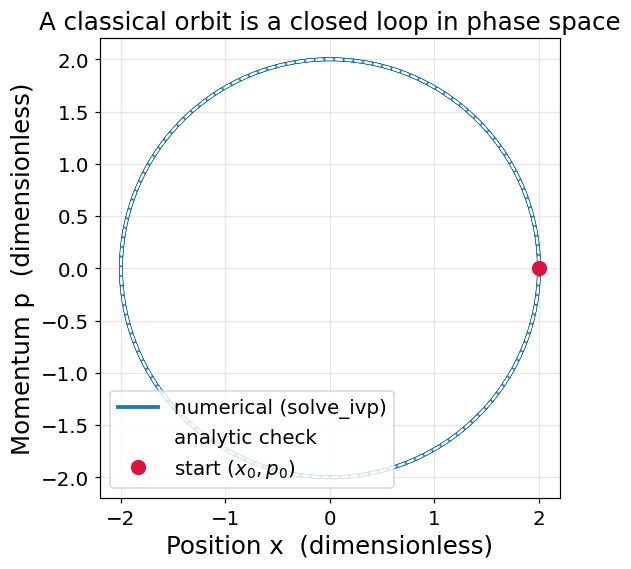

In [4]:
def hamilton_rhs(t, state, m=m, omega=omega):
    '''Right-hand side of Hamilton's equations for solve_ivp.

    state = [x, p];  returns [dx/dt, dp/dt] = [p/m, -m*omega^2*x].
    '''
    x, p = state
    dxdt = p / m
    dpdt = -m * omega**2 * x
    return [dxdt, dpdt]

# One full period of the oscillator is T = 2*pi/omega.
T = 2 * np.pi / omega
t_span = (0.0, 2 * T)                       # simulate two periods
t_eval = np.linspace(*t_span, 600)          # times at which to store the state

x0, p0 = 2.0, 0.0                           # initial condition: released from x=2, at rest
sol = solve_ivp(hamilton_rhs, t_span, [x0, p0],
                t_eval=t_eval, method="RK45", rtol=1e-9, atol=1e-9)

# Analytic solution (our answer key): x(t)=x0 cos(wt)+(p0/(m w)) sin(wt).
x_exact = x0*np.cos(omega*sol.t) + (p0/(m*omega))*np.sin(omega*sol.t)
p_exact = -m*omega*x0*np.sin(omega*sol.t) + p0*np.cos(omega*sol.t)
max_dev = np.max(np.hypot(sol.y[0]-x_exact, sol.y[1]-p_exact))
print(f"Max numerical-vs-analytic deviation = {max_dev:.2e}  (should be ~0 -> solver is correct)")

fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.plot(sol.y[0], sol.y[1], color="#1f77b4", lw=2.5, label="numerical (solve_ivp)")
ax.plot(x_exact, p_exact, "--", color="white", lw=1.2, label="analytic check")
ax.plot(x0, p0, "o", color="crimson", ms=9, label="start $(x_0,p_0)$")
ax.set_xlabel("Position x  (dimensionless)")
ax.set_ylabel("Momentum p  (dimensionless)")
ax.set_title("A classical orbit is a closed loop in phase space")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig("fig_c1_single_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption.** *Phase-space trajectory of one oscillator started at rest at $x_0=2$ (red dot). The motion traces a single closed circle, returning exactly to its start after each period — the hallmark of energy-conserving, deterministic classical dynamics.*


### (b) Many random initial conditions
Each starting point sits on its own energy circle. Plotting many at once reveals the nested, non-crossing structure of phase space — and we save the data for later ML use.


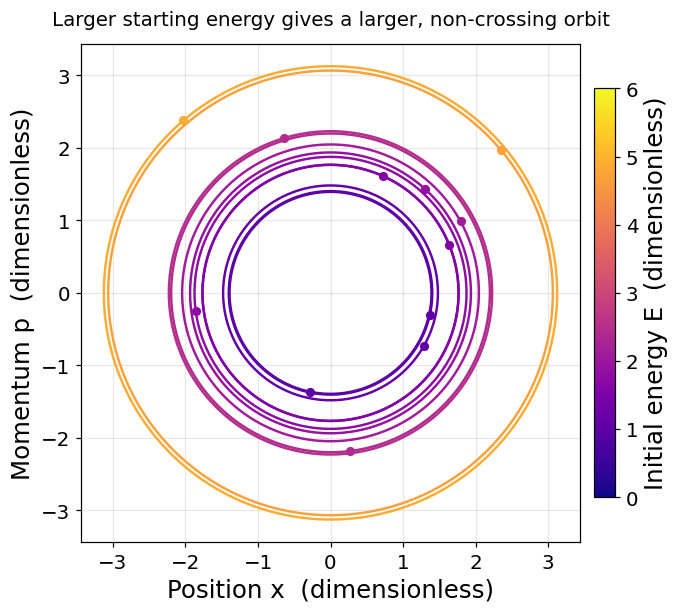

Saved 12 trajectories to classical_trajectories.npy


In [5]:
rng = np.random.default_rng(42)        # fixed seed -> reproducible
n_traj = 12
trajectories = []                       # will store arrays for saving

fig, ax = plt.subplots(figsize=(7.4, 5.8))
# Color each trajectory by its (conserved) energy using a perceptual colormap.
cmap = plt.cm.plasma
for k in range(n_traj):
    x0 = rng.uniform(-2.5, 2.5)
    p0 = rng.uniform(-2.5, 2.5)
    sol = solve_ivp(hamilton_rhs, (0, T), [x0, p0],
                    t_eval=np.linspace(0, T, 400),
                    method="RK45", rtol=1e-9, atol=1e-9)
    E0 = energy(x0, p0)
    color = cmap(E0 / 6.0)              # normalize energy to [0,1] for color
    ax.plot(sol.y[0], sol.y[1], color=color, lw=1.6)
    ax.plot(x0, p0, "o", color=color, ms=5)
    # store time, x, p for this trajectory
    trajectories.append(np.vstack([sol.t, sol.y[0], sol.y[1]]).T)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 6))
cbar = fig.colorbar(sm, ax=ax, shrink=0.82, pad=0.02); cbar.set_label("Initial energy E  (dimensionless)")
ax.set_xlabel("Position x  (dimensionless)")
ax.set_ylabel("Momentum p  (dimensionless)")
ax.set_title("Larger starting energy gives a larger, non-crossing orbit", fontsize=13, pad=12)
ax.set_aspect("equal"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_c1_many_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

# Save the generated classical data for Component 3 (ragged -> object array).
data_array = np.array(trajectories, dtype=object)
np.save("classical_trajectories.npy", data_array)
print(f"Saved {n_traj} trajectories to classical_trajectories.npy")

**Figure caption.** *Phase-space trajectories for 12 random initial conditions, colored by their conserved energy. Each is a closed circle whose radius grows with energy; trajectories never intersect (a unique state has a unique future). This nested structure is the classical "feature space" that Component 3 will learn from.*


### Sanity check — is energy actually conserved?
A correct integration must keep $E$ constant along each trajectory. We verify numerically.


In [6]:
# Re-integrate one orbit and track its energy over time.
sol = solve_ivp(hamilton_rhs, (0, 4*T), [1.5, 0.5],
                t_eval=np.linspace(0, 4*T, 2000),
                method="RK45", rtol=1e-10, atol=1e-10)
E_t = energy(sol.y[0], sol.y[1])
drift = E_t.max() - E_t.min()
print(f"Energy min/max over 4 periods: {E_t.min():.10f} / {E_t.max():.10f}")
print(f"Total energy drift: {drift:.2e}  (should be ~1e-8 or smaller -> conserved)")
assert drift < 1e-6, "Energy not conserved -> tighten solver tolerances!"
print("PASS: energy is conserved -> the numerical pipeline is trustworthy.")

Energy min/max over 4 periods: 1.2499999981 / 1.2500000000
Total energy drift: 1.91e-09  (should be ~1e-8 or smaller -> conserved)
PASS: energy is conserved -> the numerical pipeline is trustworthy.


---
## Component 1 — takeaways
- The harmonic oscillator's energy $E(x,p)=\tfrac{p^2}{2m}+\tfrac12 m\omega^2 x^2$ defines closed contours in phase space (circles here, ellipses in general units).
- Hamilton's equations $\dot x = p/m,\ \dot p = -m\omega^2 x$ move the state around those contours; `solve_ivp` integrates them reliably.
- Trajectories are closed, non-crossing, and energy-conserving — verified numerically.
- **Output for Component 3:** `classical_trajectories.npy` (the classical input features) and the saved figures.

*Next: Component 2 builds the quantum version of this same oscillator and produces the prediction targets.*
